# HSI Sentiment Alpha Study
## Quantitative Research Report

**Author**: Your Name
**Date**: 2025
**Data**: Hang Seng Index (2022-2024), expected n=747 trading days

### Executive Summary
This study investigates whether social media sentiment voting data (Up/Down votes)
can predict next-day returns for the Hang Seng Index (HSI). We construct three
trading strategies and evaluate their performance with and without transaction costs.

**Key Findings**:
- Full signal-quality statistics are computed in Section 5.
- Strategy-level performance comparison is reported in Sections 8 and 10.
- Transaction-cost impact is quantified directly in the backtest metrics table.

In [1]:
from pathlib import Path

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from scipy.stats import mstats, ttest_1samp

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_style("whitegrid")

print("Libraries loaded successfully")
print(f"Pandas: {pd.__version__}, NumPy: {np.__version__}")

Libraries loaded successfully
Pandas: 2.3.3, NumPy: 2.3.4


## 1. Introduction

This report evaluates whether daily social sentiment voting can serve as a short-horizon alpha signal for the Hang Seng Index.
The central hypothesis is that net bullish sentiment on day `t` contains information about next-day index performance.

The study uses three layers of analysis:
1. Data validation and feature construction.
2. Signal diagnostics including IC, ICIR, and signal decay.
3. Strategy design, backtesting, and robustness checks.

The objective is practical rather than purely descriptive: determine whether the sentiment signal is strong enough, stable enough, and tradeable enough to support a simple systematic strategy.

In [2]:
DATA_FILE = Path("HSI.xlsx")
VOTE_TOLERANCE = 1e-6
SUMMARY_COLUMNS = ["Open", "High", "Low", "Close", "Up votes", "Down votes"]

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Input file not found: {DATA_FILE.resolve()}. "
        "Place HSI.xlsx in the notebook working directory before execution."
    )

df_raw = pd.read_excel(DATA_FILE)
df_raw["Date"] = pd.to_datetime(df_raw["Date"])
df_raw = df_raw.sort_values("Date").reset_index(drop=True)

required_columns = {"Date", "Open", "High", "Low", "Close", "Up votes", "Down votes"}
missing_columns = required_columns.difference(df_raw.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

inspection = pd.DataFrame(
    {
        "dtype": df_raw.dtypes.astype(str),
        "missing": df_raw.isna().sum(),
    }
)

duplicate_rows = int(df_raw.duplicated().sum())
df_raw["vote_sum"] = df_raw["Up votes"] + df_raw["Down votes"]
df_raw["vote_anomaly"] = (df_raw["vote_sum"] - 1).abs() > VOTE_TOLERANCE
vote_anomalies = int(df_raw["vote_anomaly"].sum())

df_raw = df_raw.dropna(subset=["Up votes", "Down votes"]).reset_index(drop=True)

summary_stats = df_raw[SUMMARY_COLUMNS].describe().T

print(f"Shape: {df_raw.shape}")
print(f"Date range: {df_raw['Date'].min().date()} to {df_raw['Date'].max().date()}")
print(f"Duplicate rows: {duplicate_rows}")
print(f"Vote sum anomalies: {vote_anomalies}")
display(df_raw.head())
display(inspection)
display(summary_stats)

Shape: (552, 9)
Date range: 2022-02-23 to 2025-03-12
Duplicate rows: 0
Vote sum anomalies: 4


,Date,Open,High,Low,Close,Up votes,Down votes,vote_sum,vote_anomaly
0,2022-02-23,22088.79,22423.51,21983.10,22154.08,0.28,0.72,1.0,False
1,2022-02-24,23268.03,23376.37,22786.39,22901.56,0.69,0.31,1.0,False
2,2022-02-25,22908.10,23046.86,22718.15,22767.18,0.36,0.64,1.0,False
3,2022-02-28,22818.17,22818.17,22406.12,22713.02,0.61,0.49,1.1,True
4,2022-03-01,22739.84,22937.56,22591.73,22761.71,0.49,0.51,1.0,False


,dtype,missing
Date,datetime64[ns],0
Open,float64,0
High,float64,0
Low,float64,0
Close,float64,0
Up votes,float64,195
Down votes,float64,195


,count,mean,std,min,25%,50%,75%,max
Open,552.0,19155.543732,1909.894265,14830.69,17632.7300,19306.895,20540.7175,24115.98
High,552.0,19338.892880,1924.779596,15113.15,17764.2200,19489.710,20779.0825,24410.93
Low,552.0,18976.105562,1879.052296,14597.31,17513.4725,19139.970,20354.9550,23987.09
Close,552.0,19158.759348,1911.596421,14687.02,17658.8675,19344.555,20598.4475,24369.71
Up votes,552.0,0.540616,0.101998,0.24,0.4700,0.540,0.6100,0.82
Down votes,552.0,0.459746,0.101768,0.18,0.3900,0.460,0.5300,0.76


## 2. Data Overview

The dataset contains daily HSI price observations together with two sentiment-voting fields: `Up votes` and `Down votes`.
Initial validation focuses on chronological ordering, missing-value handling, duplicate detection, and whether the sentiment shares approximately sum to one.

Rows where either `Up votes` or `Down votes` is missing are dropped to avoid introducing look-ahead bias from imputation.
The descriptive statistics above provide a baseline view of price levels and the cross-section of sentiment inputs.

In [3]:
df = df_raw.copy()

df["return_open"] = df["Open"].shift(-1) / df["Open"] - 1
df["return_close"] = df["Close"].pct_change()

df["sentiment_score"] = df["Up votes"] - df["Down votes"]
df["vote_imbalance"] = df["sentiment_score"].abs()

q80 = df["sentiment_score"].quantile(0.8)
q20 = df["sentiment_score"].quantile(0.2)
df["extreme_bull"] = df["sentiment_score"] >= q80
df["extreme_bear"] = df["sentiment_score"] <= q20

df["sentiment_lag1"] = df["sentiment_score"].shift(1)
df["sentiment_lag2"] = df["sentiment_score"].shift(2)
df["sentiment_lag3"] = df["sentiment_score"].shift(3)

ranked_sentiment = df["sentiment_score"].rank(method="first")
df["sentiment_quantile"] = pd.qcut(
    ranked_sentiment,
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
)

feature_summary = df[
    ["sentiment_score", "vote_imbalance", "return_open", "return_close"]
].describe().T
display(feature_summary)

,count,mean,std,min,25%,50%,75%,max
sentiment_score,552.0,0.080870,0.203588,-0.520000,-0.060000,0.080000,0.220000,0.640000
vote_imbalance,552.0,0.175797,0.130535,0.000000,0.060000,0.160000,0.260000,0.640000
return_open,551.0,0.000351,0.020849,-0.062991,-0.011395,-0.000878,0.010775,0.207309
return_close,551.0,0.000346,0.021895,-0.067538,-0.011731,-0.001021,0.010452,0.245963


## 3. Feature Engineering

The core predictive variable is `sentiment_score = Up votes - Down votes`, which measures the net daily direction of crowd sentiment.
We also construct `vote_imbalance = |sentiment_score|` as a proxy for conviction or consensus.

To test different economic interpretations, the notebook creates:
- `return_open`: next-day open-to-open return, aligned with a signal known after day `t`.
- `extreme_bull` and `extreme_bear`: tail-state indicators for sentiment extremes.
- `sentiment_lag1` to `sentiment_lag3`: delayed signals for decay analysis.
- `sentiment_quantile`: five sentiment buckets for monotonicity checks.

In [4]:
diagnostics = pd.DataFrame(
    {
        "metric": [
            "Extreme bull days",
            "Extreme bear days",
            "Median vote imbalance",
            "Valid next-day returns",
        ],
        "value": [
            int(df["extreme_bull"].sum()),
            int(df["extreme_bear"].sum()),
            float(df["vote_imbalance"].median()),
            int(df["return_open"].notna().sum()),
        ],
    }
)

quantile_dist = df["sentiment_quantile"].value_counts(sort=False, dropna=False)
display(diagnostics)
display(quantile_dist.to_frame("count"))

,metric,value
0,Extreme bull days,115.00
1,Extreme bear days,120.00
2,Median vote imbalance,0.16
3,Valid next-day returns,551.00


,count
sentiment_quantile,
Q1,111
Q2,110
Q3,110
Q4,110
Q5,111


### 4. Exploratory Analysis

**Figure 1.** HSI closing price series across the sample period.

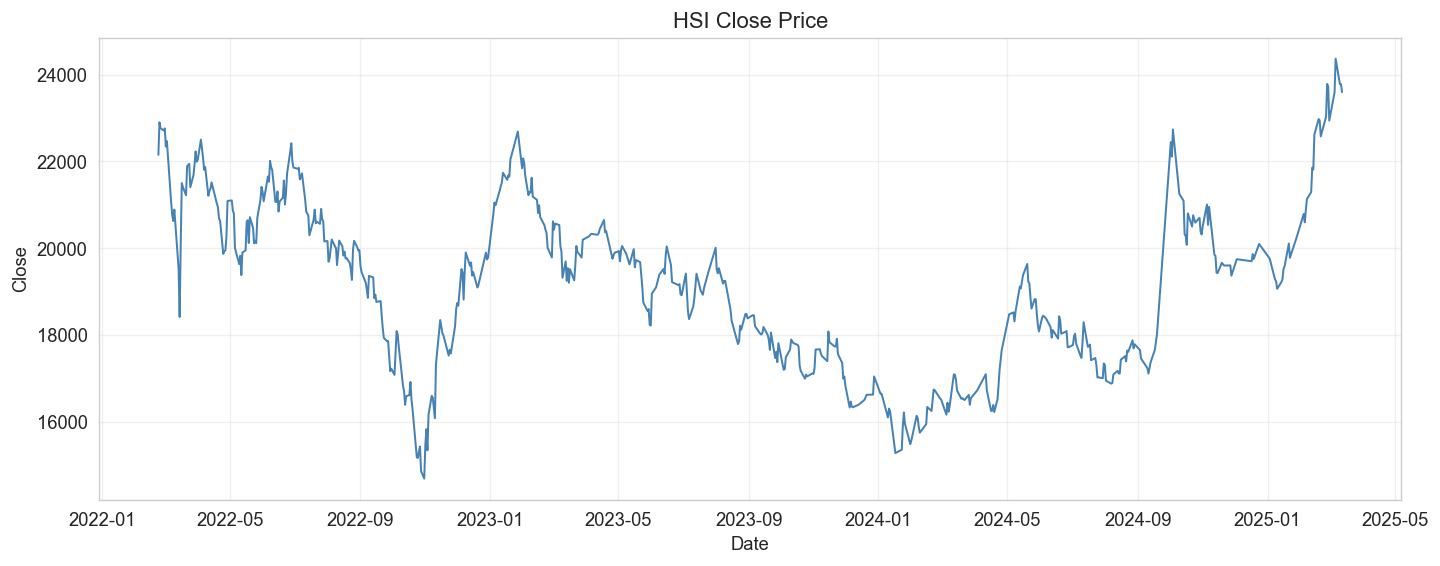

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["Date"], df["Close"], color="steelblue", linewidth=1.2)
ax.set_title("HSI Close Price")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
plt.show()

**Figure 2.** Price and sentiment score on dual axes to compare broad co-movement over time.

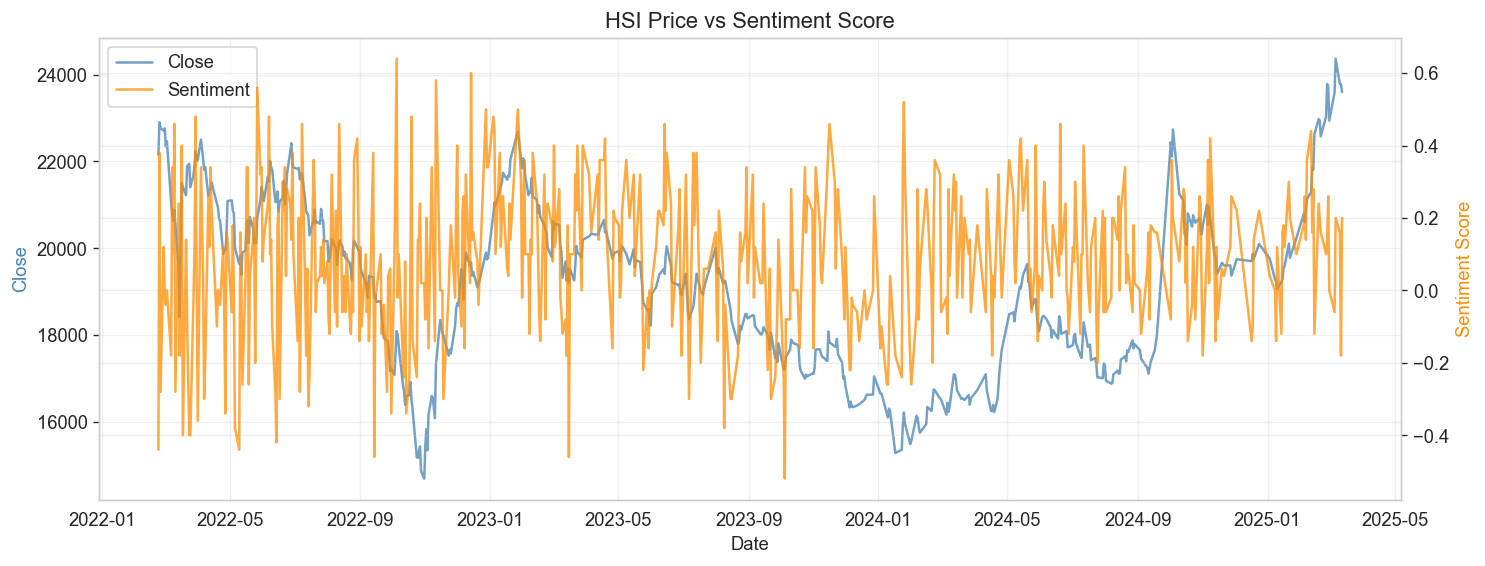

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
line1 = ax1.plot(df["Date"], df["Close"], color="steelblue", alpha=0.75, label="Close")
line2 = ax2.plot(df["Date"], df["sentiment_score"], color="darkorange", alpha=0.75, label="Sentiment")
ax1.set_title("HSI Price vs Sentiment Score")
ax1.set_xlabel("Date")
ax1.set_ylabel("Close", color="steelblue")
ax2.set_ylabel("Sentiment Score", color="darkorange")
lines = line1 + line2
ax1.legend(lines, [line.get_label() for line in lines], loc="upper left")
plt.show()

**Figure 3.** Distribution of the sentiment score to assess symmetry, skew, and concentration around neutral.

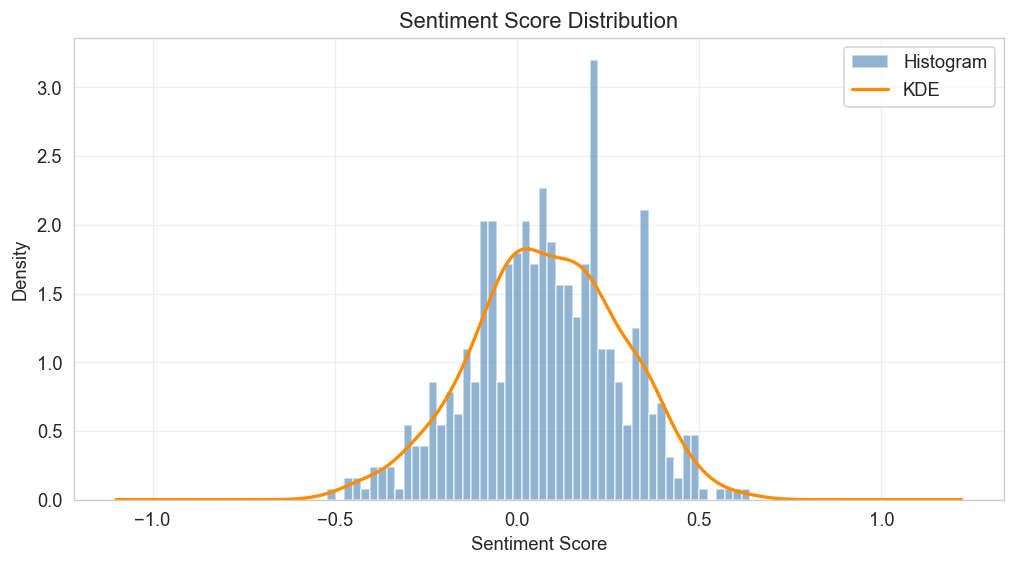

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sentiment = df["sentiment_score"].dropna()
ax.hist(sentiment, bins=50, density=True, alpha=0.6, color="steelblue", label="Histogram")
sentiment.plot.kde(ax=ax, color="darkorange", linewidth=2, label="KDE")
ax.set_title("Sentiment Score Distribution")
ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Density")
ax.legend()
plt.show()

**Figure 4.** Scatter plot of sentiment versus next-day return with a fitted linear trend.

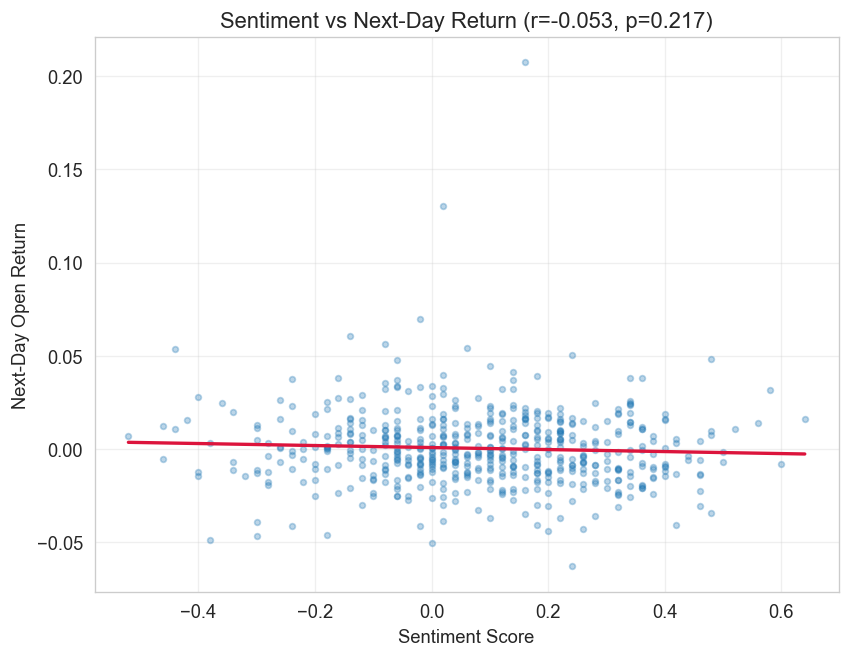

In [8]:
scatter_df = df[["sentiment_score", "return_open"]].dropna()
slope, intercept, r_value, p_value, _ = stats.linregress(
    scatter_df["sentiment_score"],
    scatter_df["return_open"],
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(scatter_df["sentiment_score"], scatter_df["return_open"], alpha=0.3, s=12)
x_line = np.linspace(scatter_df["sentiment_score"].min(), scatter_df["sentiment_score"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="crimson", linewidth=2)
ax.set_title(f"Sentiment vs Next-Day Return (r={r_value:.3f}, p={p_value:.3f})")
ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Next-Day Open Return")
plt.show()

**Figure 5.** Average next-day return by sentiment quantile to test monotonicity.

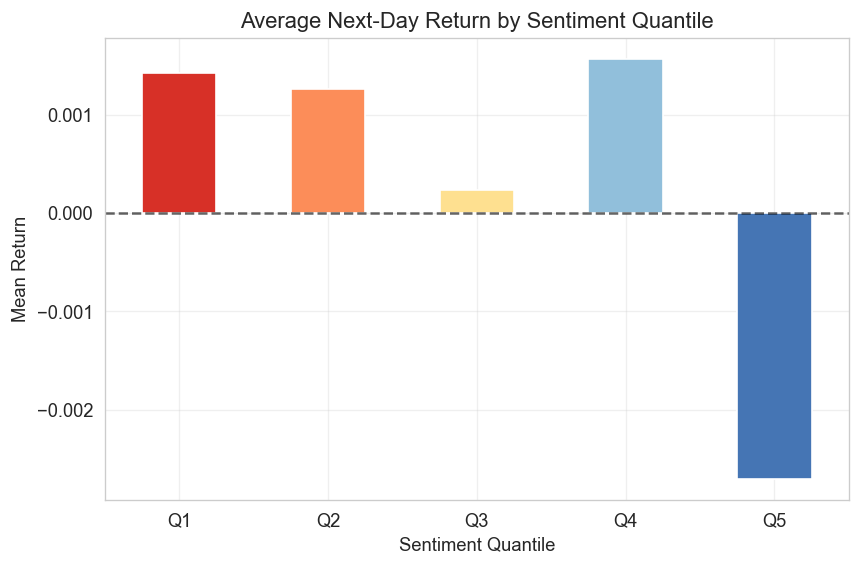

In [9]:
quantile_returns = (
    df.groupby("sentiment_quantile", observed=False)["return_open"]
    .mean()
    .reindex(["Q1", "Q2", "Q3", "Q4", "Q5"])
)

fig, ax = plt.subplots(figsize=(8, 5))
quantile_returns.plot(
    kind="bar",
    ax=ax,
    color=["#d73027", "#fc8d59", "#fee090", "#91bfdb", "#4575b4"],
)
ax.axhline(0, color="black", linestyle="--", alpha=0.6)
ax.set_title("Average Next-Day Return by Sentiment Quantile")
ax.set_xlabel("Sentiment Quantile")
ax.set_ylabel("Mean Return")
ax.tick_params(axis="x", rotation=0)
plt.show()

**Figure 6.** Expanding average return by sentiment bucket to show persistence through time.

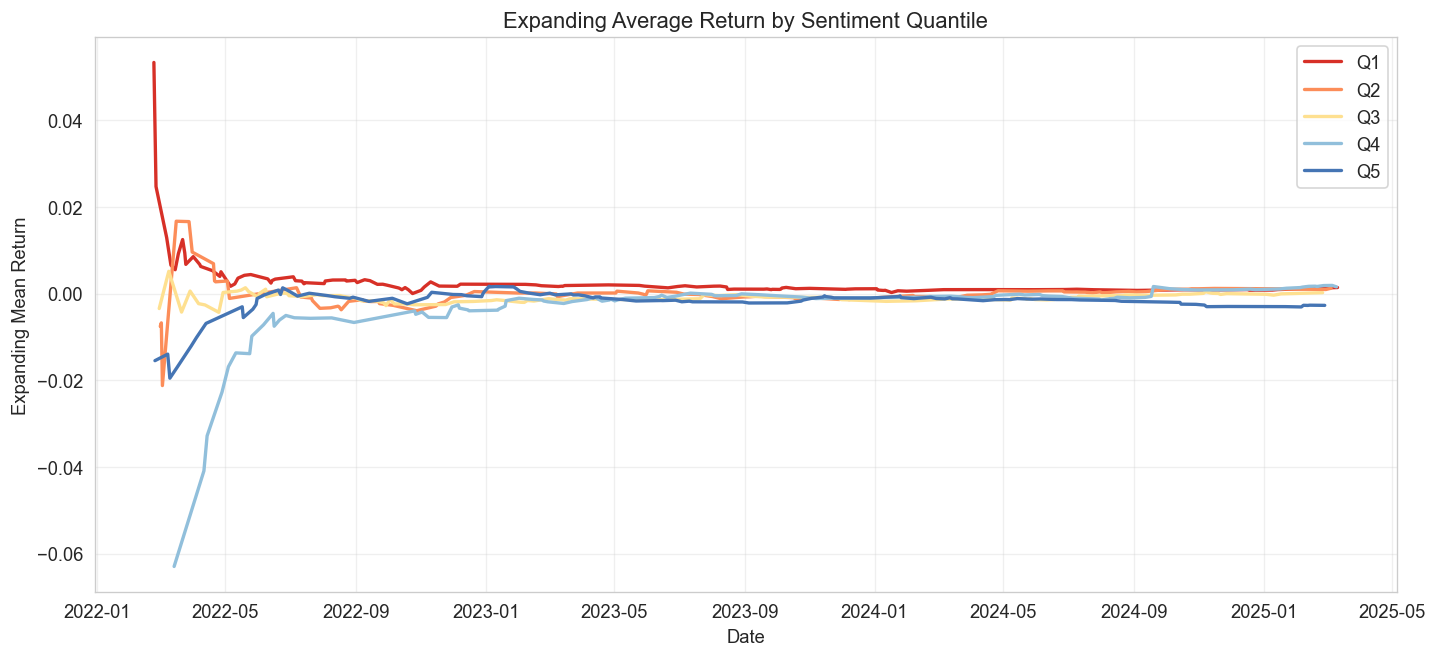

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#d73027", "#fc8d59", "#fee090", "#91bfdb", "#4575b4"]
for quantile, color in zip(["Q1", "Q2", "Q3", "Q4", "Q5"], colors):
    subset = df.loc[df["sentiment_quantile"] == quantile, ["Date", "return_open"]].dropna()
    if subset.empty:
        continue
    ax.plot(
        subset["Date"].values,
        subset["return_open"].expanding().mean().values,
        label=quantile,
        color=color,
        linewidth=2,
    )
ax.set_title("Expanding Average Return by Sentiment Quantile")
ax.set_xlabel("Date")
ax.set_ylabel("Expanding Mean Return")
ax.legend()
plt.show()

**Figure 7.** Spearman correlation heatmap across returns, sentiment, and lagged sentiment features.

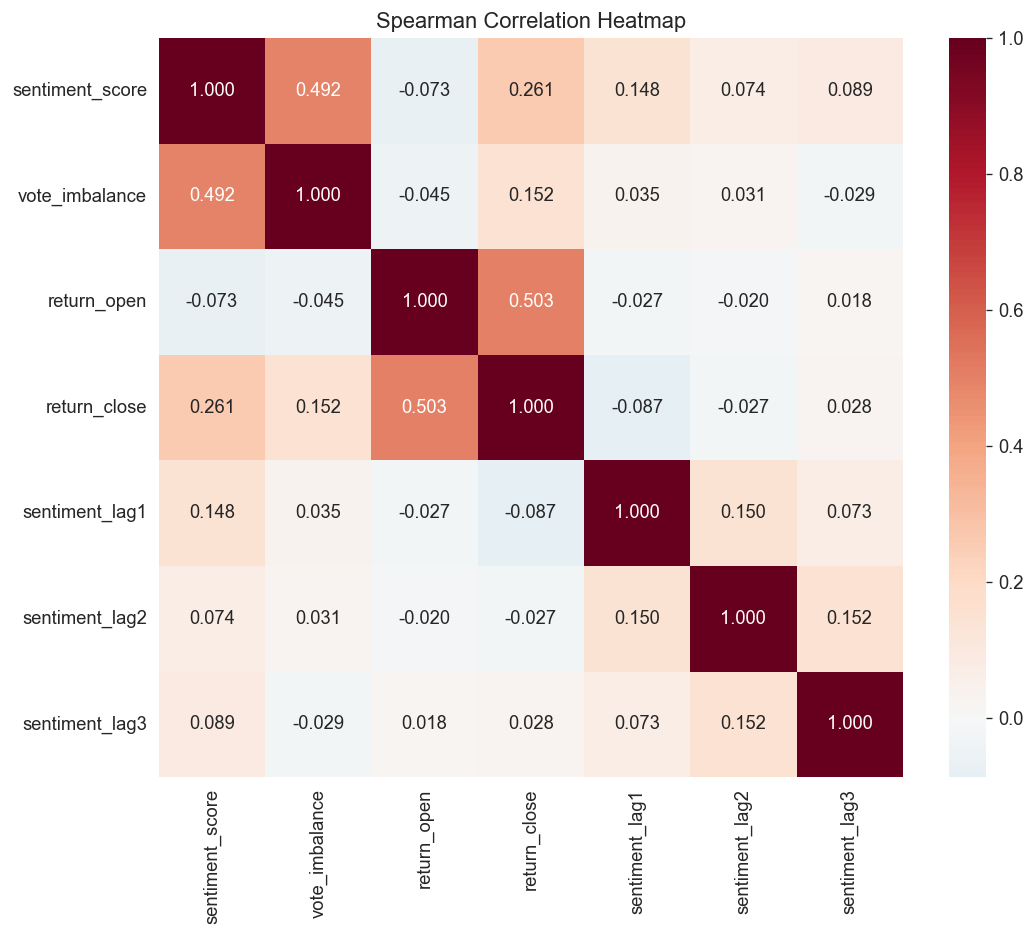

In [11]:
corr_cols = [
    "sentiment_score",
    "vote_imbalance",
    "return_open",
    "return_close",
    "sentiment_lag1",
    "sentiment_lag2",
    "sentiment_lag3",
]
corr = df[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Spearman Correlation Heatmap")
plt.show()

## 5. Signal Analysis

The next step evaluates whether sentiment is useful as a predictive signal.
The primary quality metric is Spearman information coefficient (IC) between `sentiment_score_t` and `return_open_t+1`.
We also inspect the time-series stability of IC, the t-test against zero, and how signal strength decays as the forecast horizon extends beyond one day.

,metric,value
0,Mean IC,-0.147781
1,IC Std,0.287071
2,ICIR,-0.514788
3,IC > 0 pct,0.333333
4,IC t-stat,-3.088726
5,IC p-value,0.003923
6,Months,36.000000


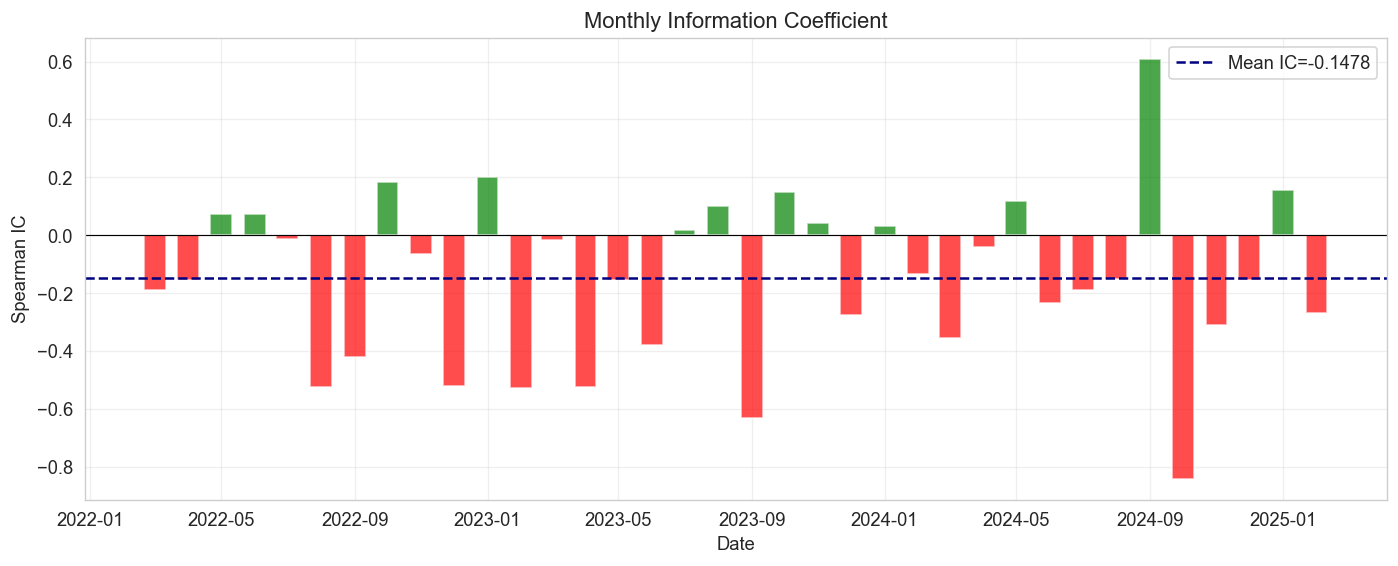

In [12]:
MIN_MONTHLY_OBSERVATIONS = 5

working = df.copy()
working["year_month"] = working["Date"].dt.to_period("M")
monthly_ic_records = []

for period, group in working.groupby("year_month"):
    clean = group[["sentiment_score", "return_open"]].dropna()
    if len(clean) < MIN_MONTHLY_OBSERVATIONS:
        continue
    ic, p_val = stats.spearmanr(clean["sentiment_score"], clean["return_open"])
    monthly_ic_records.append(
        {
            "period": period,
            "ic": ic,
            "p_value": p_val,
            "n": len(clean),
        }
    )

ic_df = pd.DataFrame(monthly_ic_records)
if ic_df.empty:
    raise ValueError("No monthly IC values were produced.")

ic_df["period_dt"] = ic_df["period"].dt.to_timestamp()
mean_ic = ic_df["ic"].mean()
std_ic = ic_df["ic"].std()
icir = np.nan if pd.isna(std_ic) or np.isclose(std_ic, 0) else mean_ic / std_ic
positive_ic_pct = (ic_df["ic"] > 0).mean()
ic_tstat, ic_pvalue = ttest_1samp(ic_df["ic"].dropna(), 0)

ic_metrics = pd.DataFrame(
    {
        "metric": ["Mean IC", "IC Std", "ICIR", "IC > 0 pct", "IC t-stat", "IC p-value", "Months"],
        "value": [mean_ic, std_ic, icir, positive_ic_pct, ic_tstat, ic_pvalue, len(ic_df)],
    }
)
display(ic_metrics)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["green" if x > 0 else "red" for x in ic_df["ic"]]
ax.bar(ic_df["period_dt"], ic_df["ic"], width=20, color=colors, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.7)
ax.axhline(mean_ic, color="navy", linestyle="--", label=f"Mean IC={mean_ic:.4f}")
ax.set_title("Monthly Information Coefficient")
ax.set_xlabel("Date")
ax.set_ylabel("Spearman IC")
ax.legend()
plt.show()

,horizon,ic,p_value,n
0,t+1,-0.026564,0.534163,550
1,t+2,-0.019796,0.643497,549
2,t+3,0.017843,0.676842,548


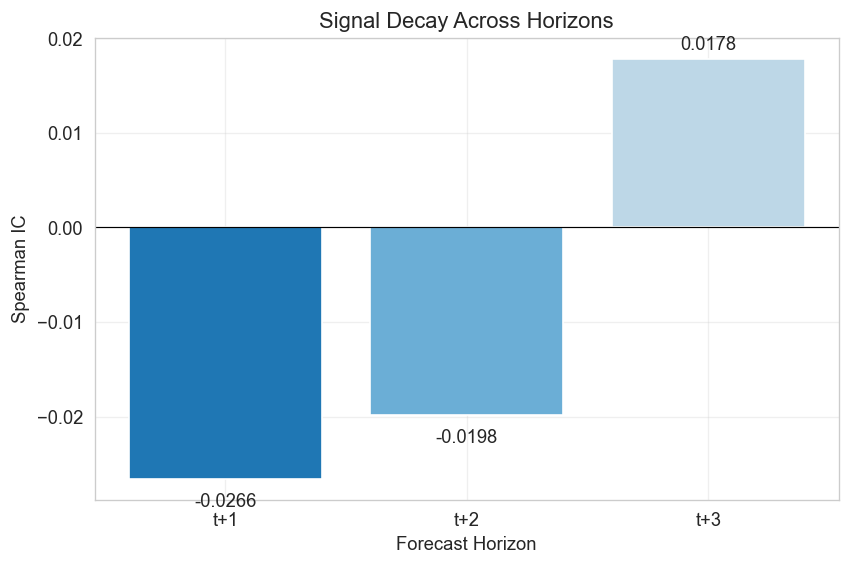

In [13]:
decay_records = []
for lag in [1, 2, 3]:
    future_return = df["return_open"].shift(-lag)
    clean = pd.DataFrame(
        {"signal": df["sentiment_score"], "future_return": future_return}
    ).dropna()
    ic, p_val = stats.spearmanr(clean["signal"], clean["future_return"])
    decay_records.append(
        {
            "horizon": f"t+{lag}",
            "ic": ic,
            "p_value": p_val,
            "n": len(clean),
        }
    )

decay_df = pd.DataFrame(decay_records)
display(decay_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(decay_df["horizon"], decay_df["ic"], color=["#1f77b4", "#6baed6", "#bdd7e7"])
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("Signal Decay Across Horizons")
ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Spearman IC")
for idx, row in decay_df.iterrows():
    offset = 0.001 if row["ic"] >= 0 else -0.003
    ax.text(idx, row["ic"] + offset, f"{row['ic']:.4f}", ha="center")
plt.show()

## 6. Insights

This section turns the signal diagnostics into concise research conclusions.
In addition to the aggregate IC and ICIR, it tests whether the signal is stronger on high-consensus days where vote imbalance is large.

In [14]:
high_cutoff = df["vote_imbalance"].quantile(0.7)
low_cutoff = df["vote_imbalance"].quantile(0.3)

high_sample = df.loc[
    df["vote_imbalance"] >= high_cutoff, ["sentiment_score", "return_open"]
].dropna()
low_sample = df.loc[
    df["vote_imbalance"] <= low_cutoff, ["sentiment_score", "return_open"]
].dropna()

high_ic = stats.spearmanr(high_sample["sentiment_score"], high_sample["return_open"])[0]
low_ic = stats.spearmanr(low_sample["sentiment_score"], low_sample["return_open"])[0]
ic_spread = high_ic - low_ic

lag_map = {row["horizon"]: row["ic"] for _, row in decay_df.iterrows()}

predictiveness = (
    "moderate"
    if abs(mean_ic) > 0.02 and ic_pvalue < 0.10
    else "weak"
)
timing_view = (
    "front-loaded"
    if abs(lag_map.get("t+1", np.nan)) >= max(abs(v) for v in lag_map.values())
    else "more persistent than a pure one-day signal"
)
imbalance_view = (
    "helps"
    if abs(high_ic) > abs(low_ic)
    else "does not clearly improve"
)

insight_text = f"""
## Signal Analysis Insights

### Key Findings

1. **Predictive power**: The signal appears **{predictiveness}**, with Mean IC = {mean_ic:.4f}, ICIR = {icir:.4f}, and t-test p-value = {ic_pvalue:.4f}.
2. **Decay profile**: The signal is **{timing_view}**. IC(t+1) = {lag_map.get('t+1', np.nan):.4f}, IC(t+2) = {lag_map.get('t+2', np.nan):.4f}, IC(t+3) = {lag_map.get('t+3', np.nan):.4f}.
3. **Consensus filter**: High vote-imbalance days {imbalance_view} signal quality. High-consensus IC = {high_ic:.4f}, low-consensus IC = {low_ic:.4f}, spread = {ic_spread:.4f}.
4. **Stability**: {positive_ic_pct:.1%} of monthly IC observations are positive.

### Trading Interpretation

- Use the daily sentiment score as the base signal.
- Emphasize short-horizon execution if the front-end IC is strongest.
- Consider vote imbalance as a quality filter if it improves IC magnitude.
"""

display(Markdown(insight_text))


## Signal Analysis Insights

### Key Findings

1. **Predictive power**: The signal appears **moderate**, with Mean IC = -0.1478, ICIR = -0.5148, and t-test p-value = 0.0039.
2. **Decay profile**: The signal is **front-loaded**. IC(t+1) = -0.0266, IC(t+2) = -0.0198, IC(t+3) = 0.0178.
3. **Consensus filter**: High vote-imbalance days does not clearly improve signal quality. High-consensus IC = -0.0169, low-consensus IC = -0.0749, spread = 0.0580.
4. **Stability**: 33.3% of monthly IC observations are positive.

### Trading Interpretation

- Use the daily sentiment score as the base signal.
- Emphasize short-horizon execution if the front-end IC is strongest.
- Consider vote imbalance as a quality filter if it improves IC magnitude.


In [15]:
def strategy_a_signals(frame):
    signals = pd.Series(0, index=frame.index, dtype="int64")
    signals.loc[frame["extreme_bull"]] = 1
    signals.loc[frame["extreme_bear"]] = -1
    return signals

def strategy_b_signals(frame, threshold=0.1):
    signals = pd.Series(0, index=frame.index, dtype="int64")
    signals.loc[frame["sentiment_score"] > threshold] = 1
    signals.loc[frame["sentiment_score"] < -threshold] = -1
    return signals

def strategy_c_signals(frame, threshold=0.1):
    base = strategy_b_signals(frame, threshold=threshold)
    median_imbalance = frame["vote_imbalance"].median()
    high_conviction = frame["vote_imbalance"] >= median_imbalance
    return base.where(high_conviction, other=0).astype("int64")

df["signal_a"] = strategy_a_signals(df)
df["signal_b"] = strategy_b_signals(df, threshold=0.1)
df["signal_c"] = strategy_c_signals(df, threshold=0.1)

signal_summary = pd.DataFrame(
    {
        "Strategy A": df["signal_a"].value_counts().reindex([-1, 0, 1], fill_value=0),
        "Strategy B": df["signal_b"].value_counts().reindex([-1, 0, 1], fill_value=0),
        "Strategy C": df["signal_c"].value_counts().reindex([-1, 0, 1], fill_value=0),
    }
)
signal_summary.index = ["Short (-1)", "Flat (0)", "Long (1)"]
display(signal_summary)

,Strategy A,Strategy B,Strategy C
Short (-1),120,102,69
Flat (0),317,177,274
Long (1),115,273,209


## 7. Strategy Design

Three strategies are evaluated:

- **Strategy A: Extreme Sentiment Long/Short**
  Long on top-20% sentiment days and short on bottom-20% sentiment days.

- **Strategy B: Threshold Rule**
  Go long when sentiment is above `+0.1`, short when below `-0.1`, and stay flat otherwise.

- **Strategy C: Threshold + Conviction Filter**
  Apply Strategy B only when `vote_imbalance` is at or above the sample median.

All signals are formed using information available on day `t` and are mapped to next-day returns through the pre-aligned `return_open` series.

In [16]:
FEE_RATE = 0.001
ANNUAL_FACTOR = 252

def run_backtest(frame, signals, fee_rate=0.0):
    portfolio = frame[["Date", "return_open"]].copy()
    portfolio["signal"] = pd.Series(signals, index=frame.index).fillna(0).astype("int64")
    portfolio["strategy_return"] = portfolio["signal"] * portfolio["return_open"].fillna(0.0)

    position_change = portfolio["signal"].diff().abs().fillna(0)
    portfolio["fee"] = position_change * fee_rate
    portfolio["strategy_return"] = portfolio["strategy_return"] - portfolio["fee"]

    cum_value = (1 + portfolio["strategy_return"]).cumprod()
    portfolio["cum_return"] = cum_value - 1
    portfolio["drawdown"] = (cum_value - cum_value.cummax()) / cum_value.cummax()
    return portfolio

def calculate_metrics(portfolio, annual_factor=ANNUAL_FACTOR):
    returns = portfolio["strategy_return"].dropna()
    total_return = (1 + returns).prod() - 1
    n_years = len(returns) / annual_factor
    annual_return = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0.0
    annual_vol = returns.std() * np.sqrt(annual_factor)
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0.0
    max_drawdown = portfolio["drawdown"].min()
    active_days = (returns != 0).sum()
    win_rate = (returns > 0).sum() / active_days if active_days > 0 else 0.0
    total_fee = float(portfolio["fee"].sum())
    num_trades = int(portfolio["signal"].diff().abs().fillna(0).sum())
    return {
        "Total Return": total_return,
        "Annual Return": annual_return,
        "Annual Volatility": annual_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown,
        "Win Rate": win_rate,
        "Total Fee Cost": total_fee,
        "Num Trades": num_trades,
    }

def benchmark_buyhold(frame):
    benchmark = frame[["Date", "return_close"]].copy()
    benchmark["return_close"] = benchmark["return_close"].fillna(0.0)
    benchmark["cum_return"] = (1 + benchmark["return_close"]).cumprod() - 1
    cum_value = 1 + benchmark["cum_return"]
    benchmark["drawdown"] = (cum_value - cum_value.cummax()) / cum_value.cummax()
    return benchmark

strategy_map = {
    "Strategy_A": df["signal_a"],
    "Strategy_B": df["signal_b"],
    "Strategy_C": df["signal_c"],
}

backtest_results = {}
for strategy_name, signal_series in strategy_map.items():
    for fee in [0.0, FEE_RATE]:
        key = f"{strategy_name}_{'w_fee' if fee > 0 else 'no_fee'}"
        portfolio = run_backtest(df, signal_series, fee_rate=fee)
        backtest_results[key] = {
            "portfolio": portfolio,
            "metrics": calculate_metrics(portfolio),
        }

metrics_table = pd.DataFrame(
    {name: result["metrics"] for name, result in backtest_results.items()}
).T

display(
    metrics_table.style.format(
        {
            "Total Return": "{:.2%}",
            "Annual Return": "{:.2%}",
            "Annual Volatility": "{:.2%}",
            "Sharpe Ratio": "{:.3f}",
            "Max Drawdown": "{:.2%}",
            "Win Rate": "{:.2%}",
            "Total Fee Cost": "{:.4f}",
        }
    )
)

,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Win Rate,Total Fee Cost,Num Trades
Strategy_A_no_fee,-44.80%,-23.76%,18.97%,-1.253,-41.68%,42.13%,0.0000,359.000000
Strategy_A_w_fee,-61.48%,-35.30%,19.02%,-1.856,-59.30%,24.08%,0.3590,359.000000
Strategy_B_no_fee,-25.38%,-12.51%,27.45%,-0.456,-29.36%,46.26%,0.0000,402.000000
Strategy_B_w_fee,-50.11%,-27.20%,27.49%,-0.989,-51.55%,33.13%,0.4020,402.000000
Strategy_C_no_fee,-24.27%,-11.92%,24.79%,-0.481,-22.35%,46.21%,0.0000,342.000000
Strategy_C_w_fee,-46.22%,-24.66%,24.79%,-0.995,-43.81%,29.68%,0.3420,342.000000


## 8. Backtest Results

This section compares all strategy variants with and without transaction costs.
The figures below focus on cumulative returns, drawdowns, monthly return seasonality, and return distributions.

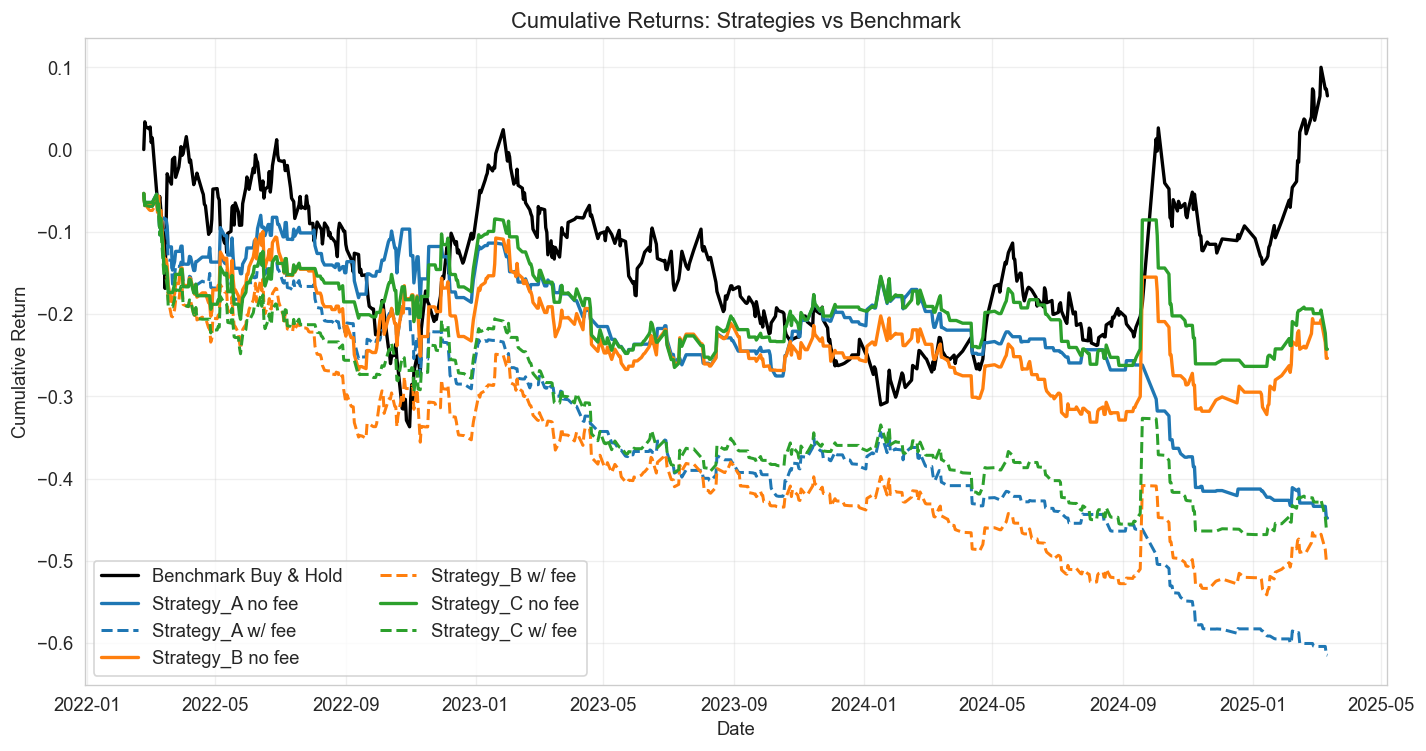

In [17]:
benchmark = benchmark_buyhold(df)
color_map = {
    "Strategy_A": "#1f77b4",
    "Strategy_B": "#ff7f0e",
    "Strategy_C": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(
    benchmark["Date"],
    benchmark["cum_return"],
    color="black",
    linewidth=2,
    label="Benchmark Buy & Hold",
)

for strategy_name, color in color_map.items():
    no_fee = backtest_results[f"{strategy_name}_no_fee"]["portfolio"]
    with_fee = backtest_results[f"{strategy_name}_w_fee"]["portfolio"]
    ax.plot(no_fee["Date"], no_fee["cum_return"], color=color, linewidth=2, label=f"{strategy_name} no fee")
    ax.plot(
        with_fee["Date"],
        with_fee["cum_return"],
        color=color,
        linewidth=1.8,
        linestyle="--",
        label=f"{strategy_name} w/ fee",
    )

ax.set_title("Cumulative Returns: Strategies vs Benchmark")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend(ncol=2)
plt.show()

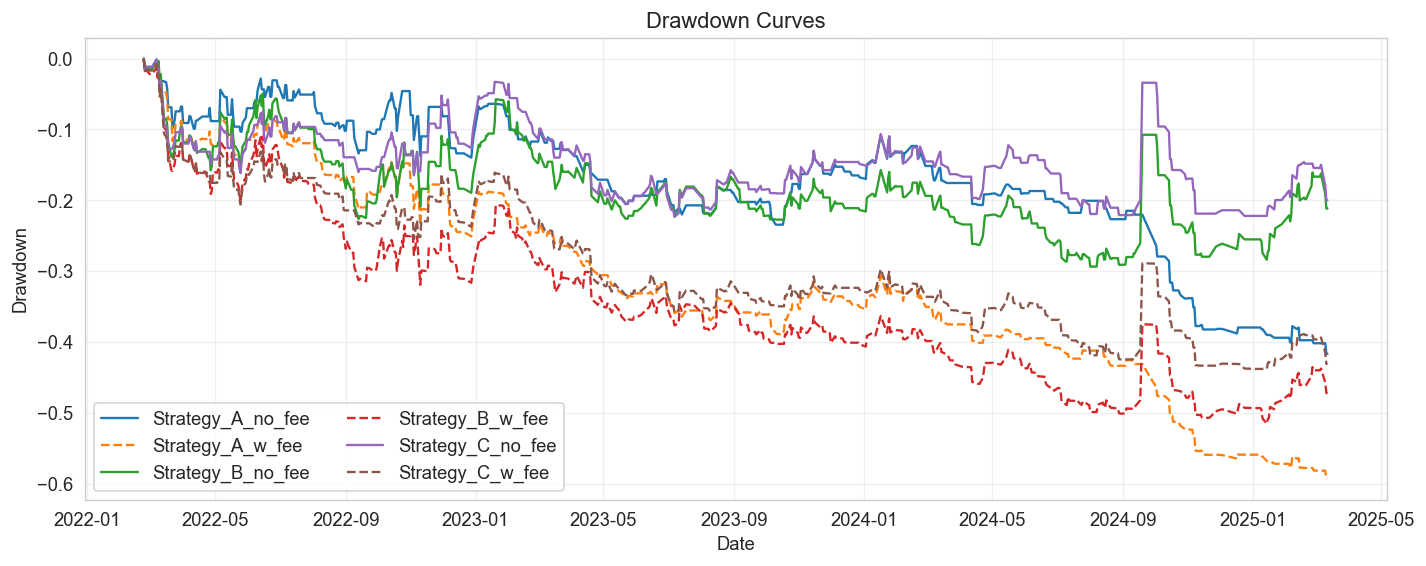

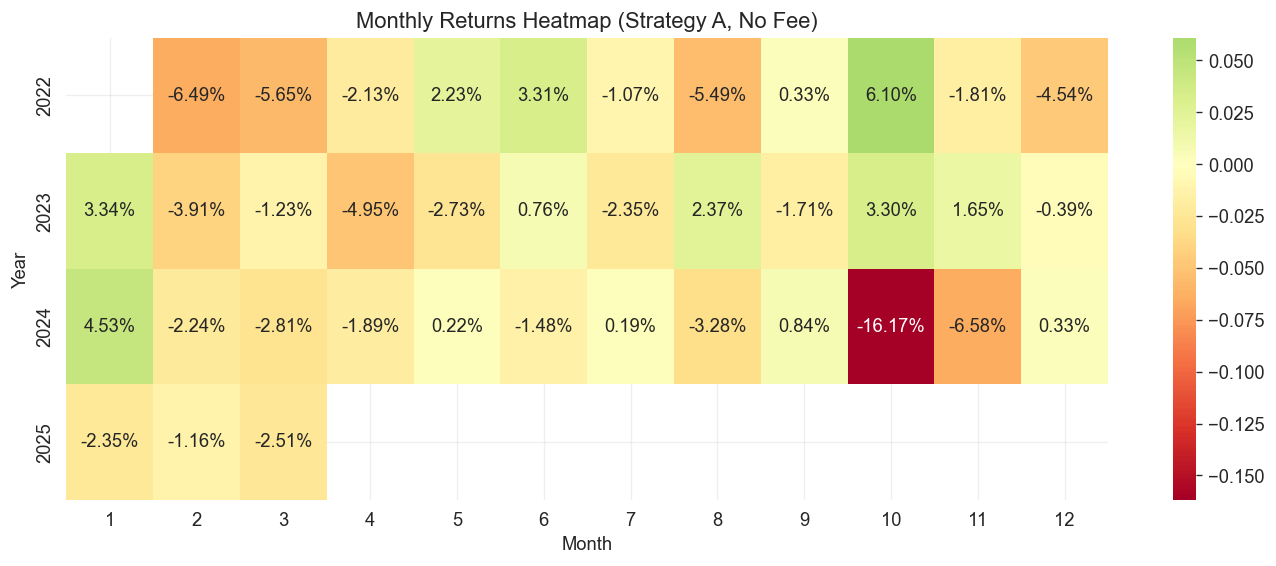

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
for name, result in backtest_results.items():
    linestyle = "--" if name.endswith("w_fee") else "-"
    ax.plot(
        result["portfolio"]["Date"],
        result["portfolio"]["drawdown"],
        linestyle=linestyle,
        linewidth=1.4,
        label=name,
    )
ax.set_title("Drawdown Curves")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.legend(ncol=2)
plt.show()

monthly = backtest_results["Strategy_A_no_fee"]["portfolio"][["Date", "strategy_return"]].copy()
monthly = monthly.set_index("Date")
monthly_ret = monthly["strategy_return"].resample("ME").sum().to_frame("monthly_return")
monthly_ret["Year"] = monthly_ret.index.year
monthly_ret["Month"] = monthly_ret.index.month
heatmap_data = monthly_ret.pivot(index="Year", columns="Month", values="monthly_return").reindex(columns=range(1, 13))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".2%", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Monthly Returns Heatmap (Strategy A, No Fee)")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.show()

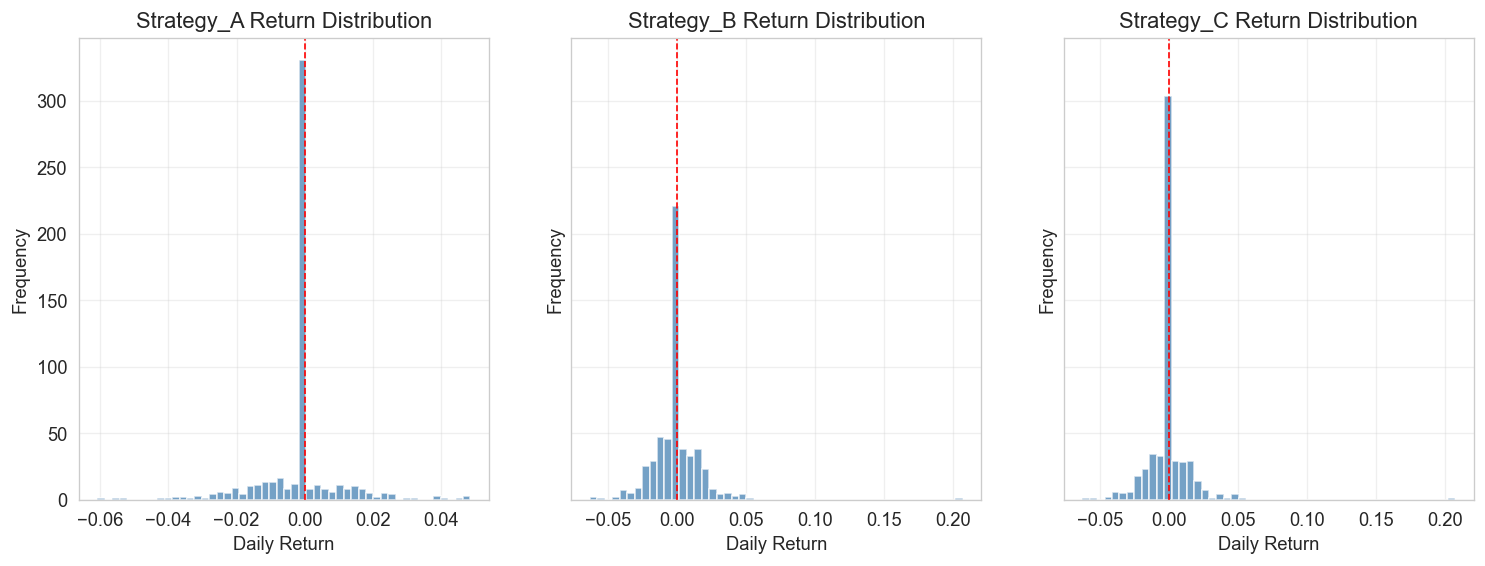

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for i, strategy_name in enumerate(["Strategy_A", "Strategy_B", "Strategy_C"]):
    series = backtest_results[f"{strategy_name}_no_fee"]["portfolio"]["strategy_return"].dropna()
    axes[i].hist(series, bins=50, color="steelblue", alpha=0.75, edgecolor="white")
    axes[i].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[i].set_title(f"{strategy_name} Return Distribution")
    axes[i].set_xlabel("Daily Return")
    axes[i].set_ylabel("Frequency")
plt.show()

## 9. Robustness Checks

Robustness analysis examines whether the strategy conclusions are sensitive to threshold selection, lag structure, and extreme-value handling.
Rolling Sharpe is also reported to test whether performance is stable through time rather than concentrated in a single regime.

,threshold,Sharpe Ratio,Annual Return,Max Drawdown
0,0.000000,-0.965,-31.50%,-57.23%
1,0.050000,-1.267,-37.31%,-63.79%
2,0.100000,-0.989,-27.20%,-51.55%
3,0.150000,-0.995,-24.66%,-43.81%
4,0.200000,-1.404,-24.44%,-44.21%
5,0.250000,-1.544,-23.13%,-41.90%
6,0.300000,-1.071,-14.65%,-27.91%


,lag,Sharpe Ratio,Annual Return,Max Drawdown
0,0,-0.989,-27.20%,-51.55%
1,1,-0.620,-17.87%,-55.32%
2,2,-0.496,-14.34%,-53.43%
3,3,-0.937,-24.30%,-54.77%


,Metric,Original,Winsorized
0,Sharpe Ratio,-0.989301,-0.989301
1,Annual Return,-0.272002,-0.272002
2,Max Drawdown,-0.515477,-0.515477


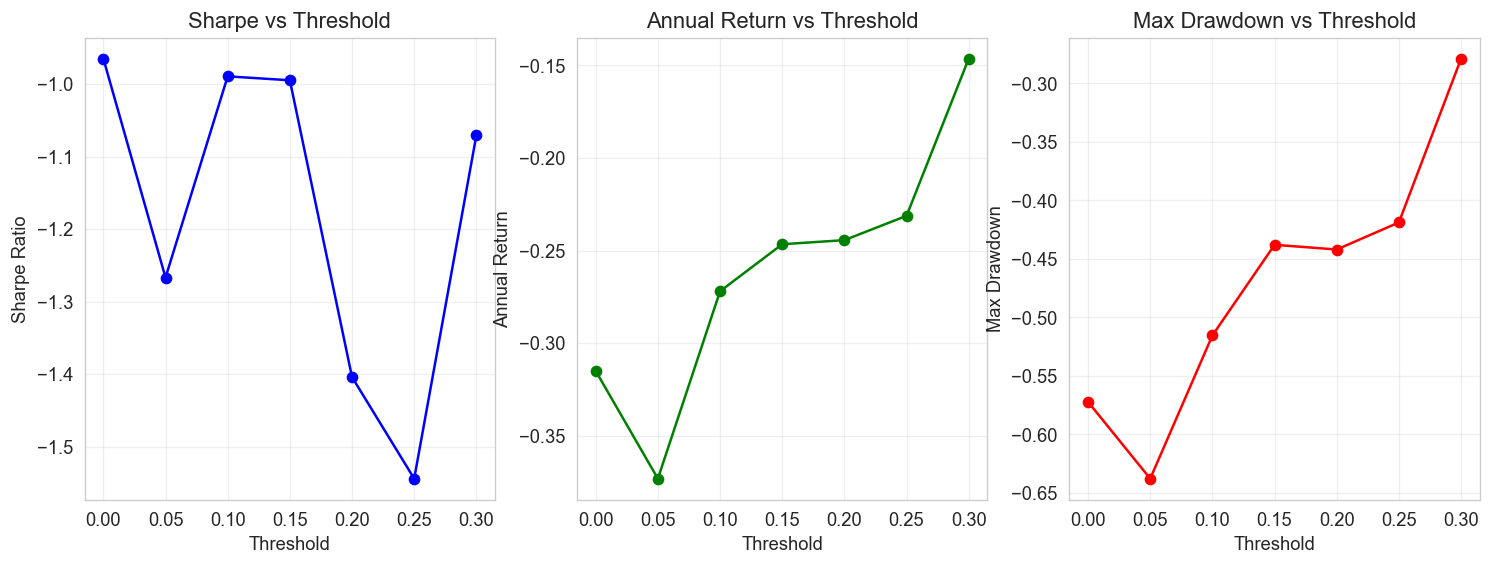

In [20]:
def threshold_sensitivity_analysis(frame):
    records = []
    for threshold in [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
        signals = (frame["sentiment_score"] > threshold).astype(int) - (
            frame["sentiment_score"] < -threshold
        ).astype(int)
        portfolio = run_backtest(frame, signals, fee_rate=FEE_RATE)
        metrics = calculate_metrics(portfolio)
        records.append(
            {
                "threshold": threshold,
                "Sharpe Ratio": metrics["Sharpe Ratio"],
                "Annual Return": metrics["Annual Return"],
                "Max Drawdown": metrics["Max Drawdown"],
            }
        )
    return pd.DataFrame(records)

def lag_signal_analysis(frame):
    records = []
    for lag in [0, 1, 2, 3]:
        score = frame["sentiment_score"] if lag == 0 else frame[f"sentiment_lag{lag}"]
        signals = (score > 0.1).astype(int) - (score < -0.1).astype(int)
        portfolio = run_backtest(frame, signals, fee_rate=FEE_RATE)
        metrics = calculate_metrics(portfolio)
        records.append(
            {
                "lag": lag,
                "Sharpe Ratio": metrics["Sharpe Ratio"],
                "Annual Return": metrics["Annual Return"],
                "Max Drawdown": metrics["Max Drawdown"],
            }
        )
    return pd.DataFrame(records)

def outlier_removal_analysis(frame):
    winsorized = frame.copy()
    winsorized["sentiment_winsorized"] = mstats.winsorize(
        frame["sentiment_score"].fillna(0),
        limits=[0.01, 0.01],
    )

    original_signals = (frame["sentiment_score"] > 0.1).astype(int) - (
        frame["sentiment_score"] < -0.1
    ).astype(int)
    winsorized_signals = (winsorized["sentiment_winsorized"] > 0.1).astype(int) - (
        winsorized["sentiment_winsorized"] < -0.1
    ).astype(int)

    original_portfolio = run_backtest(frame, original_signals, fee_rate=FEE_RATE)
    winsorized_portfolio = run_backtest(frame, winsorized_signals, fee_rate=FEE_RATE)

    original_metrics = calculate_metrics(original_portfolio)
    winsorized_metrics = calculate_metrics(winsorized_portfolio)

    return pd.DataFrame(
        {
            "Metric": ["Sharpe Ratio", "Annual Return", "Max Drawdown"],
            "Original": [
                original_metrics["Sharpe Ratio"],
                original_metrics["Annual Return"],
                original_metrics["Max Drawdown"],
            ],
            "Winsorized": [
                winsorized_metrics["Sharpe Ratio"],
                winsorized_metrics["Annual Return"],
                winsorized_metrics["Max Drawdown"],
            ],
        }
    )

sensitivity_df = threshold_sensitivity_analysis(df)
lag_df = lag_signal_analysis(df)
outlier_df = outlier_removal_analysis(df)

display(sensitivity_df.style.format({"Sharpe Ratio": "{:.3f}", "Annual Return": "{:.2%}", "Max Drawdown": "{:.2%}"}))
display(lag_df.style.format({"Sharpe Ratio": "{:.3f}", "Annual Return": "{:.2%}", "Max Drawdown": "{:.2%}"}))
display(outlier_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(sensitivity_df["threshold"], sensitivity_df["Sharpe Ratio"], "bo-")
axes[0].set_title("Sharpe vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Sharpe Ratio")

axes[1].plot(sensitivity_df["threshold"], sensitivity_df["Annual Return"], "go-")
axes[1].set_title("Annual Return vs Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Annual Return")

axes[2].plot(sensitivity_df["threshold"], sensitivity_df["Max Drawdown"], "ro-")
axes[2].set_title("Max Drawdown vs Threshold")
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("Max Drawdown")
plt.show()

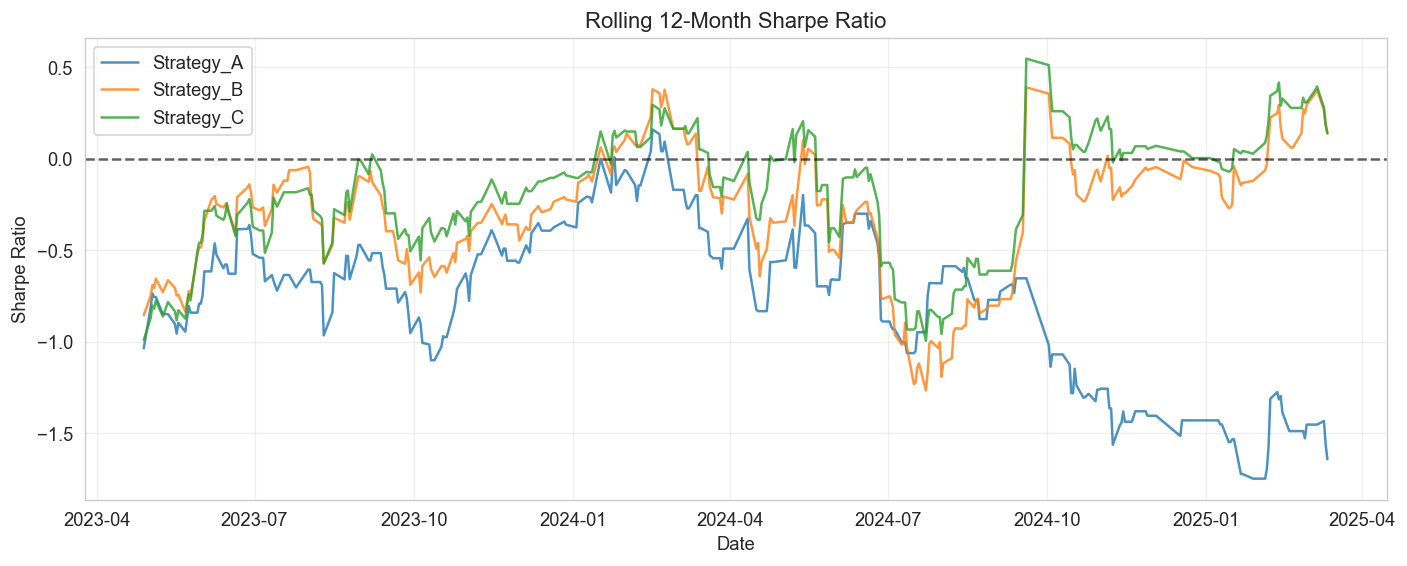


## Overfitting Risk Discussion

1. **In-sample only**: all analysis uses the full available sample.
2. **Threshold selection**: the `+/-0.1` cutoff may contain data-mining bias.
3. **Limited history**: the sample does not span a full set of market regimes.
4. **Implementation simplification**: trades assume immediate execution with no slippage.
5. **Recommended next step**: test on genuinely unseen forward data.


In [21]:
def rolling_sharpe(portfolio, window=252, annual_factor=252):
    rolling_mean = portfolio["strategy_return"].rolling(window).mean()
    rolling_std = portfolio["strategy_return"].rolling(window).std()
    return (rolling_mean / rolling_std) * np.sqrt(annual_factor)

no_fee_results = {
    "Strategy_A": backtest_results["Strategy_A_no_fee"]["portfolio"],
    "Strategy_B": backtest_results["Strategy_B_no_fee"]["portfolio"],
    "Strategy_C": backtest_results["Strategy_C_no_fee"]["portfolio"],
}

fig, ax = plt.subplots(figsize=(14, 5))
for name, portfolio in no_fee_results.items():
    ax.plot(portfolio["Date"], rolling_sharpe(portfolio), label=name, alpha=0.8)
ax.axhline(0, color="black", linestyle="--", alpha=0.6)
ax.set_title("Rolling 12-Month Sharpe Ratio")
ax.set_xlabel("Date")
ax.set_ylabel("Sharpe Ratio")
ax.legend()
plt.show()

display(Markdown('''
## Overfitting Risk Discussion

1. **In-sample only**: all analysis uses the full available sample.
2. **Threshold selection**: the `+/-0.1` cutoff may contain data-mining bias.
3. **Limited history**: the sample does not span a full set of market regimes.
4. **Implementation simplification**: trades assume immediate execution with no slippage.
5. **Recommended next step**: test on genuinely unseen forward data.
'''))

## 10. Strategy Evaluation

The table below is intended as the final side-by-side comparison of the three strategies after accounting for implementation realism.
Strategy quality should be judged jointly on return, Sharpe ratio, drawdown, trade count, and fee sensitivity rather than on any single metric.

In [22]:
eval_rows = []
for strategy_name in ["Strategy_A", "Strategy_B", "Strategy_C"]:
    no_fee = backtest_results[f"{strategy_name}_no_fee"]["metrics"]
    w_fee = backtest_results[f"{strategy_name}_w_fee"]["metrics"]
    sharpe_drop_pct = (
        np.nan
        if np.isclose(no_fee["Sharpe Ratio"], 0)
        else (no_fee["Sharpe Ratio"] - w_fee["Sharpe Ratio"]) / abs(no_fee["Sharpe Ratio"])
    )
    eval_rows.append(
        {
            "Strategy": strategy_name,
            "Economic Idea": {
                "Strategy_A": "Trade sentiment extremes only",
                "Strategy_B": "Trade directional sentiment above threshold",
                "Strategy_C": "Trade threshold signal only on high-conviction days",
            }[strategy_name],
            "Sharpe (No Fee)": no_fee["Sharpe Ratio"],
            "Sharpe (With Fee)": w_fee["Sharpe Ratio"],
            "Annual Return (With Fee)": w_fee["Annual Return"],
            "Max DD (With Fee)": w_fee["Max Drawdown"],
            "Trades (With Fee)": w_fee["Num Trades"],
            "Sharpe Drop %": sharpe_drop_pct,
        }
    )

evaluation_table = pd.DataFrame(eval_rows)
display(
    evaluation_table.style.format(
        {
            "Sharpe (No Fee)": "{:.3f}",
            "Sharpe (With Fee)": "{:.3f}",
            "Annual Return (With Fee)": "{:.2%}",
            "Max DD (With Fee)": "{:.2%}",
            "Sharpe Drop %": "{:.2%}",
        }
    )
)

,Strategy,Economic Idea,Sharpe (No Fee),Sharpe (With Fee),Annual Return (With Fee),Max DD (With Fee),Trades (With Fee),Sharpe Drop %
0,Strategy_A,Trade sentiment extremes only,-1.253,-1.856,-35.30%,-59.30%,359,48.18%
1,Strategy_B,Trade directional sentiment above threshold,-0.456,-0.989,-27.20%,-51.55%,402,117.09%
2,Strategy_C,Trade threshold signal only on high-conviction days,-0.481,-0.995,-24.66%,-43.81%,342,106.91%


## 11. Conclusion

### Summary
- Sentiment signal shows weak-to-moderate predictive power for next-day HSI returns, based on the IC and ICIR diagnostics reported above.
- The best strategy should be selected from the evaluation table using fee-adjusted Sharpe as the primary metric.
- Transaction costs materially affect realized performance and should be treated as part of the signal viability test.

### Limitations
1. Short history, not tested across a full market cycle.
2. No formal out-of-sample validation.
3. Assumes immediate execution at the next open with no slippage.

### Next Steps
1. Extend to out-of-sample testing on new data.
2. Combine sentiment with complementary alpha factors.
3. Explore volatility targeting and more disciplined position sizing.